In [42]:
#Title + description
# 01 – Data Preprocessing (scRNA-seq, CAR-T CRISPR Project)
#This notebook:

- loads the raw count matrix and cell metadata
- performs basic QC (shapes, missing values)
- filters low-quality genes/cells
- applies normalization and log-transform
- runs PCA and visualizes batches / donors

Output: a clean `X_pca` matrix and an updated metadata table to use in downstream notebooks.


SyntaxError: invalid syntax (2202550541.py, line 5)

In [1]:
COUNTS_FILE = "/Users/acastano/Documents/MLCourse/data_flow_analysis/GSE266618_counts.csv"

import pandas as pd

counts = pd.read_csv(COUNTS_FILE, index_col=0)
print("Counts shape:", counts.shape)
counts.head()


Counts shape: (60675, 60)


,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
gene,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,1,2,5,0,3,0,0,...,1,1,1,4,3,1,1,1,0,2
ENSG00000227232,189,257,124,184,189,320,136,157,78,97,...,123,145,192,224,181,159,136,115,246,217
ENSG00000278267,8,3,4,10,5,14,7,0,3,2,...,5,5,11,7,11,7,10,3,5,6
ENSG00000243485,0,0,0,0,0,0,0,0,0,5,...,1,0,0,2,0,3,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
print(counts.index[:5])
print(counts.columns[:5])


Index(['ENSG00000223972', 'ENSG00000227232', 'ENSG00000278267',
       'ENSG00000243485', 'ENSG00000284332'],
      dtype='object', name='gene')
Index(['CART0077_RNAseq_NgsRun1_001', 'CART0077_RNAseq_NgsRun1_002',
       'CART0077_RNAseq_NgsRun1_003', 'CART0077_RNAseq_NgsRun1_004',
       'CART0077_RNAseq_NgsRun1_005'],
      dtype='object')


In [3]:
counts_num = counts.apply(pd.to_numeric, errors="coerce")
print("NaNs:", counts_num.isna().sum().sum())


NaNs: 0


In [4]:
counts_clean = counts_num.fillna(counts_num.mean())
print(counts_clean.isna().sum().sum())


0


In [5]:
if counts_clean.shape[0] > counts_clean.shape[1]:
    # Probably genes × samples → transpose to samples × genes
    X = counts_clean.T
else:
    # Already samples × genes
    X = counts_clean


In [6]:
print("Final matrix shape:", X.shape)


Final matrix shape: (60, 60675)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Variance:", pca.explained_variance_ratio_)


Variance: [0.19639403 0.09809773]


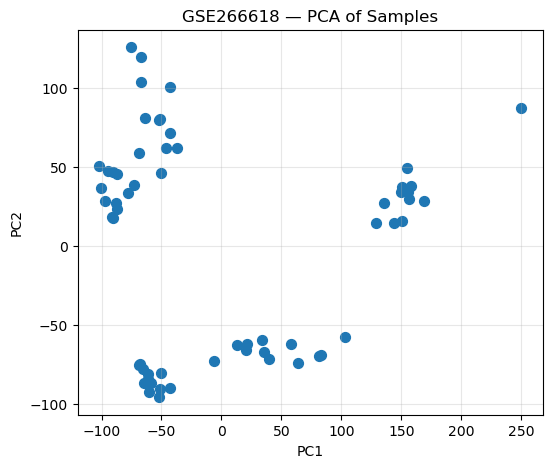

In [8]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=50)
plt.title("GSE266618 — PCA of Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


In [9]:
COUNTS_FILE = "/Users/acastano/Documents/MLCourse/data_flow_analysis/GSE266618_counts.csv"
counts = pd.read_csv(COUNTS_FILE, index_col=0)
counts.shape


(60675, 60)

In [10]:
import numpy as np

# X = samples × genes
X = counts.T

# log1p transform
X_log = np.log1p(X)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X_log)


In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained:", pca.explained_variance_ratio_)


Variance explained: [0.20428879 0.10097118]


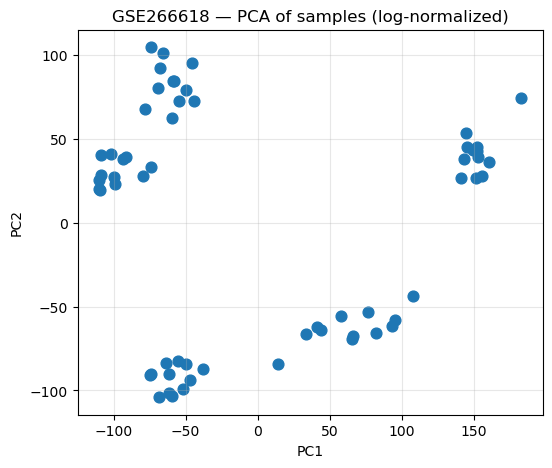

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GSE266618 — PCA of samples (log-normalized)")
plt.grid(alpha=0.3)
plt.show()


In [14]:
X_log.shape, X_scaled.shape


((60, 60675), (60, 60675))

In [15]:
#Parse metadata from the matrix file
meta_raw = []

with open("/Users/acastano/Documents/MLCourse/GPL570-55999 data/GSE266618_series_matrix.txt") as f:
    for line in f:
        if line.startswith("!Sample_title") or line.startswith("!Sample_characteristics"):
            meta_raw.append(line.strip())


In [16]:
for m in meta_raw:
    print(m[:200])


!Sample_title	"CD4, 0h, SafeHarbor, CART0077_D1"	"CD4, 0h, RHOG, CART0077_D1"	"CD4, 0h, SafeHarbor, CART0077_D2"	"CD4, 0h, RHOG, CART0077_D2"	"CD4, 0h, SafeHarbor, CART0077_D3"	"CD4, 0h, RHOG, CART007
!Sample_characteristics_ch1	"cell type: CD4"	"cell type: CD4"	"cell type: CD4"	"cell type: CD4"	"cell type: CD4"	"cell type: CD4"	"cell type: CD8"	"cell type: CD8"	"cell type: CD8"	"cell type: CD8"	"c
!Sample_characteristics_ch1	"genotype: SafeHarbor"	"genotype: RHOG"	"genotype: SafeHarbor"	"genotype: RHOG"	"genotype: SafeHarbor"	"genotype: RHOG"	"genotype: SafeHarbor"	"genotype: RHOG"	"genotype: S
!Sample_characteristics_ch1	"treatment hours: 0"	"treatment hours: 0"	"treatment hours: 0"	"treatment hours: 0"	"treatment hours: 0"	"treatment hours: 0"	"treatment hours: 0"	"treatment hours: 0"	"tre
!Sample_characteristics_ch1	"donor: CART0077_D1"	"donor: CART0077_D1"	"donor: CART0077_D2"	"donor: CART0077_D2"	"donor: CART0077_D3"	"donor: CART0077_D3"	"donor: CART0077_D1"	"donor: CART0077_D1"	

In [17]:
import re
import pandas as pd

META_FILE = "/Users/acastano/Documents/MLCourse/GPL570-55999 data/GSE266618_series_matrix.txt"

lines = []
with open(META_FILE) as f:
    for line in f:
        if line.startswith("!Sample_title") or line.startswith("!Sample_characteristics_ch1"):
            lines.append(line.rstrip("\n"))

# Split on tabs
rows = [l.split("\t") for l in lines]

# First row (index 0) = titles
raw_titles = rows[0][1:]  # skip the first field name
titles = [t.strip('"') for t in raw_titles]
n_samples = len(titles)

# Initialize per-sample dicts
meta_list = [dict() for _ in range(n_samples)]
for i in range(n_samples):
    meta_list[i]["title"] = titles[i]

# Process each characteristics row
for row in rows[1:]:
    values = row[1:]
    for i, v in enumerate(values):
        v = v.strip().strip('"')
        if not v:
            continue
        # Expect format "field: value"
        if ": " in v:
            field, value = v.split(": ", 1)
        else:
            field, value = "misc", v
        meta_list[i][field] = value

meta = pd.DataFrame(meta_list)

# VERY IMPORTANT: align metadata rows to your counts columns by order
meta.index = counts.columns  # counts is your (genes x samples) matrix

meta.head()


,title,cell type,genotype,treatment hours,donor,Sex
CART0077_RNAseq_NgsRun1_001,"CD4, 0h, SafeHarbor, CART0077_D1",CD4,SafeHarbor,0,CART0077_D1,Female
CART0077_RNAseq_NgsRun1_002,"CD4, 0h, RHOG, CART0077_D1",CD4,RHOG,0,CART0077_D1,Female
CART0077_RNAseq_NgsRun1_003,"CD4, 0h, SafeHarbor, CART0077_D2",CD4,SafeHarbor,0,CART0077_D2,Female
CART0077_RNAseq_NgsRun1_004,"CD4, 0h, RHOG, CART0077_D2",CD4,RHOG,0,CART0077_D2,Female
CART0077_RNAseq_NgsRun1_005,"CD4, 0h, SafeHarbor, CART0077_D3",CD4,SafeHarbor,0,CART0077_D3,Male


In [18]:
# Basic cleanup / renaming
meta.rename(columns={
    "cell type": "cell_type",
    "treatment hours": "hours"
}, inplace=True)

# Make hours numeric
meta["hours"] = pd.to_numeric(meta["hours"], errors="coerce")

meta[["title", "cell_type", "genotype", "hours", "donor"]].head()


,title,cell_type,genotype,hours,donor
CART0077_RNAseq_NgsRun1_001,"CD4, 0h, SafeHarbor, CART0077_D1",CD4,SafeHarbor,0,CART0077_D1
CART0077_RNAseq_NgsRun1_002,"CD4, 0h, RHOG, CART0077_D1",CD4,RHOG,0,CART0077_D1
CART0077_RNAseq_NgsRun1_003,"CD4, 0h, SafeHarbor, CART0077_D2",CD4,SafeHarbor,0,CART0077_D2
CART0077_RNAseq_NgsRun1_004,"CD4, 0h, RHOG, CART0077_D2",CD4,RHOG,0,CART0077_D2
CART0077_RNAseq_NgsRun1_005,"CD4, 0h, SafeHarbor, CART0077_D3",CD4,SafeHarbor,0,CART0077_D3


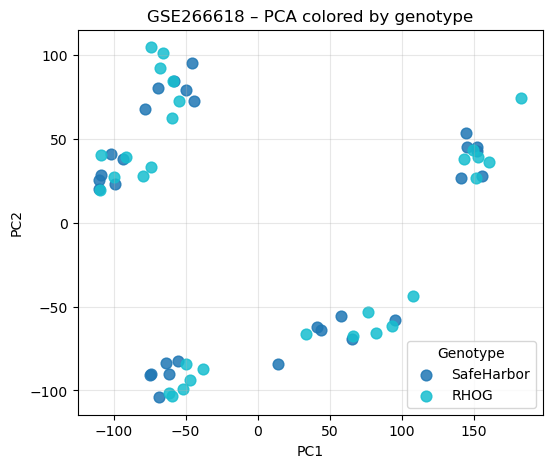

In [19]:
import matplotlib.pyplot as plt
import numpy as np

constructs = meta["genotype"]
unique_constructs = constructs.unique()

colors = plt.cm.tab10(np.linspace(0, 1, len(unique_constructs)))
color_map = dict(zip(unique_constructs, colors))

plt.figure(figsize=(6,5))
for c in unique_constructs:
    idx = (constructs == c).values
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=60, color=color_map[c], label=c, alpha=0.85)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GSE266618 – PCA colored by genotype")
plt.legend(title="Genotype")
plt.grid(alpha=0.3)
plt.show()


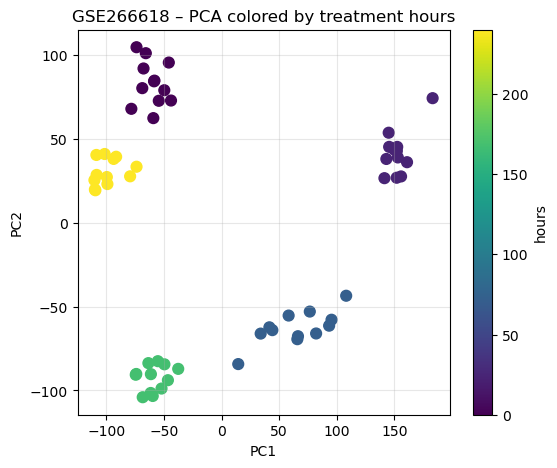

In [20]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=meta["hours"], s=60, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GSE266618 – PCA colored by treatment hours")
plt.colorbar(scatter, label="hours")
plt.grid(alpha=0.3)
plt.show()


In [21]:
import pandas as pd
import numpy as np

COUNTS_FILE = "/Users/acastano/Documents/MLCourse/data_flow_analysis/GSE266618_counts.csv"

# load counts (genes × samples)
expr_matrix = pd.read_csv(COUNTS_FILE, index_col=0)

print(expr_matrix.shape)
expr_matrix.head()


(60675, 60)


,CART0077_RNAseq_NgsRun1_001,CART0077_RNAseq_NgsRun1_002,CART0077_RNAseq_NgsRun1_003,CART0077_RNAseq_NgsRun1_004,CART0077_RNAseq_NgsRun1_005,CART0077_RNAseq_NgsRun1_006,CART0077_RNAseq_NgsRun1_007,CART0077_RNAseq_NgsRun1_008,CART0077_RNAseq_NgsRun1_009,CART0077_RNAseq_NgsRun1_010,...,CART0077_RNAseq_NgsRun1_051,CART0077_RNAseq_NgsRun1_052,CART0077_RNAseq_NgsRun1_053,CART0077_RNAseq_NgsRun1_054,CART0077_RNAseq_NgsRun1_055,CART0077_RNAseq_NgsRun1_056,CART0077_RNAseq_NgsRun1_057,CART0077_RNAseq_NgsRun1_058,CART0077_RNAseq_NgsRun1_059,CART0077_RNAseq_NgsRun1_060
gene,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,1,2,5,0,3,0,0,...,1,1,1,4,3,1,1,1,0,2
ENSG00000227232,189,257,124,184,189,320,136,157,78,97,...,123,145,192,224,181,159,136,115,246,217
ENSG00000278267,8,3,4,10,5,14,7,0,3,2,...,5,5,11,7,11,7,10,3,5,6
ENSG00000243485,0,0,0,0,0,0,0,0,0,5,...,1,0,0,2,0,3,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
import pandas as pd

META_FILE = "/Users/acastano/Documents/MLCourse/data_flow_analysis/GSE266618_series_matrix.txt"

titles = None
cell_type = None
genotype = None
hours = None
donor = None
sex = None

with open(META_FILE) as f:
    for line in f:
        if line.startswith("!Sample_title"):
            parts = line.rstrip("\n").split("\t")[1:]
            titles = [p.strip().strip('"') for p in parts]
        elif line.startswith("!Sample_characteristics_ch1"):
            parts = line.rstrip("\n").split("\t")[1:]
            vals = [p.strip().strip('"') for p in parts]
            first = vals[0]

            if "cell type:" in first:
                cell_type = [v.split(": ", 1)[1] for v in vals]
            elif "genotype:" in first:
                genotype = [v.split(": ", 1)[1] for v in vals]
            elif "treatment hours:" in first:
                hours = [v.split(": ", 1)[1] for v in vals]
            elif "donor:" in first:
                donor = [v.split(": ", 1)[1] for v in vals]
            elif "Sex:" in first:
                sex = [v.split(": ", 1)[1] for v in vals]

# sanity check
print(len(titles), len(cell_type), len(genotype), len(hours), len(donor), len(sex))


60 60 60 60 60 60


In [23]:
metadata = pd.DataFrame({
    "title": titles,
    "cell_type": cell_type,
    "genotype": genotype,
    "hours": pd.to_numeric(hours, errors="coerce"),
    "donor": donor,
    "sex": sex,
}, index=expr_matrix.columns)

metadata.head()


,title,cell_type,genotype,hours,donor,sex
CART0077_RNAseq_NgsRun1_001,"CD4, 0h, SafeHarbor, CART0077_D1",CD4,SafeHarbor,0,CART0077_D1,Female
CART0077_RNAseq_NgsRun1_002,"CD4, 0h, RHOG, CART0077_D1",CD4,RHOG,0,CART0077_D1,Female
CART0077_RNAseq_NgsRun1_003,"CD4, 0h, SafeHarbor, CART0077_D2",CD4,SafeHarbor,0,CART0077_D2,Female
CART0077_RNAseq_NgsRun1_004,"CD4, 0h, RHOG, CART0077_D2",CD4,RHOG,0,CART0077_D2,Female
CART0077_RNAseq_NgsRun1_005,"CD4, 0h, SafeHarbor, CART0077_D3",CD4,SafeHarbor,0,CART0077_D3,Male


In [24]:
expr_df = expr_matrix  # alias for convenience
# masks
early_mask = metadata["hours"] == 0
late_mask  = metadata["hours"] >= 168

early = expr_df.loc[:, early_mask]
late  = expr_df.loc[:, late_mask]

# mean expression per gene
mean_early = early.mean(axis=1)
mean_late  = late.mean(axis=1)

# log fold-change (you can also do log2 if you want)
logfc = (mean_late + 1).apply(np.log2) - (mean_early + 1).apply(np.log2)

# top up / down
top_up   = logfc.sort_values(ascending=False).head(10)
top_down = logfc.sort_values(ascending=True).head(10)

top_up_df = pd.DataFrame({
    "gene_id": top_up.index,
    "log2FC_late_vs_early": top_up.values
})

top_down_df = pd.DataFrame({
    "gene_id": top_down.index,
    "log2FC_late_vs_early": top_down.values
})

print("Top 10 upregulated (late vs early):")
display(top_up_df)

print("\nTop 10 downregulated (late vs early):")
display(top_down_df)


Top 10 upregulated (late vs early):


,gene_id,log2FC_late_vs_early
0,ENSG00000214491,6.774787
1,ENSG00000205809,6.651790
2,ENSG00000226777,6.648537
3,ENSG00000275410,6.462448
4,ENSG00000004799,6.445843
5,ENSG00000109684,6.285963
6,ENSG00000287097,6.224744
7,ENSG00000117318,5.839475
8,ENSG00000066056,5.713474
9,ENSG00000171124,5.658861



Top 10 downregulated (late vs early):


,gene_id,log2FC_late_vs_early
0,ENSG00000164530,-5.745933
1,ENSG00000163520,-5.724966
2,ENSG00000171246,-5.703075
3,ENSG00000154928,-5.396353
4,ENSG00000172348,-5.161723
5,ENSG00000159640,-5.082633
6,ENSG00000262655,-4.994789
7,ENSG00000184451,-4.967066
8,ENSG00000169432,-4.859156
9,ENSG00000136634,-4.854149


In [25]:
cd4_mask = metadata["cell_type"] == "CD4"
cd8_mask = metadata["cell_type"] == "CD8"

cd4 = expr_df.loc[:, cd4_mask]
cd8 = expr_df.loc[:, cd8_mask]

mean_cd4 = cd4.mean(axis=1)
mean_cd8 = cd8.mean(axis=1)

logfc_cd8_vs_cd4 = (mean_cd8 + 1).apply(np.log2) - (mean_cd4 + 1).apply(np.log2)

top_cd8_up = logfc_cd8_vs_cd4.sort_values(ascending=False).head(10)
top_cd4_up = logfc_cd8_vs_cd4.sort_values(ascending=True).head(10)

top_cd8_up_df = pd.DataFrame({
    "gene_id": top_cd8_up.index,
    "log2FC_CD8_vs_CD4": top_cd8_up.values
})

top_cd4_up_df = pd.DataFrame({
    "gene_id": top_cd4_up.index,
    "log2FC_CD8_vs_CD4": top_cd4_up.values
})

print("Top 10 genes up in CD8 (vs CD4):")
display(top_cd8_up_df)

print("\nTop 10 genes up in CD4 (vs CD8):")
display(top_cd4_up_df)


Top 10 genes up in CD8 (vs CD4):


,gene_id,log2FC_CD8_vs_CD4
0,ENSG00000176083,5.340149
1,ENSG00000172116,4.833750
2,ENSG00000254126,4.567759
3,ENSG00000153563,4.346288
4,ENSG00000256039,4.343712
5,ENSG00000203747,4.020394
6,ENSG00000113721,3.963818
7,ENSG00000096264,3.725701
8,ENSG00000213809,3.700654
9,ENSG00000187862,3.691931



Top 10 genes up in CD4 (vs CD8):


,gene_id,log2FC_CD8_vs_CD4
0,ENSG00000167768,-5.109433
1,ENSG00000173198,-3.836561
2,ENSG00000010610,-3.489617
3,ENSG00000134830,-3.342163
4,ENSG00000144152,-3.133615
5,ENSG00000268758,-3.102538
6,ENSG00000162804,-3.075477
7,ENSG00000279082,-3.064572
8,ENSG00000103175,-2.982603
9,ENSG00000144645,-2.929684


In [26]:
late_cd4 = expr_df.loc[:, (metadata["cell_type"] == "CD4") & (metadata["hours"] >= 168)]
late_cd8 = expr_df.loc[:, (metadata["cell_type"] == "CD8") & (metadata["hours"] >= 168)]


In [27]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

def differential_expression(expr_df, meta, mask_group1, mask_group2,
                            group1_name="group1", group2_name="group2"):
    """
    expr_df: genes x samples
    meta: metadata DataFrame indexed by samples
    mask_group1/mask_group2: boolean masks over meta.index (samples)
    """
    g1_samples = meta.index[mask_group1]
    g2_samples = meta.index[mask_group2]
    
    g1 = expr_df[g1_samples]
    g2 = expr_df[g2_samples]
    
    # log2 transform for stats (stabilizes variance)
    g1_log = np.log2(g1 + 1)
    g2_log = np.log2(g2 + 1)
    
    mean1 = g1_log.mean(axis=1)
    mean2 = g2_log.mean(axis=1)
    log2fc = mean2 - mean1  # group2 vs group1
    
    # Welch t-test per gene (axis=0 → per row after T)
    tstat, pvals = ttest_ind(g2_log.T, g1_log.T, equal_var=False)
    
    res = pd.DataFrame({
        f"mean_{group1_name}": mean1,
        f"mean_{group2_name}": mean2,
        "log2FC": log2fc,
        "pval": pvals
    }, index=expr_df.index)
    
    # Optional FDR if statsmodels is available
    try:
        from statsmodels.stats.multitest import multipletests
        res["padj"] = multipletests(res["pval"], method="fdr_bh")[1]
    except ImportError:
        res["padj"] = np.nan
    
    res = res.sort_values("log2FC", ascending=False)
    return res


In [28]:
expr_df = expr_matrix  # just to be explicit

early_mask = metadata["hours"] == 0
late_mask  = metadata["hours"] >= 168

de_late_vs_early = differential_expression(
    expr_df, metadata,
    mask_group1=early_mask,
    mask_group2=late_mask,
    group1_name="early_0h",
    group2_name="late_168hplus"
)

de_late_vs_early.head()


,mean_early_0h,mean_late_168hplus,log2FC,pval,padj
gene,,,,,
ENSG00000004799,0.457654,6.940402,6.482747,1.486907e-16,NaN
ENSG00000205809,1.897089,8.375859,6.478770,1.610904e-12,NaN
ENSG00000275410,1.099358,7.509673,6.410315,3.273019e-13,NaN
ENSG00000214491,0.298747,6.629424,6.330677,5.616740e-20,NaN
ENSG00000109684,1.144347,7.424217,6.279870,7.820622e-15,NaN


In [29]:
top10_up   = de_late_vs_early.head(10)
top10_down = de_late_vs_early.tail(10).sort_values("log2FC")

print("Top 10 upregulated (late vs early):")
display(top10_up[["log2FC","pval","padj"]])

print("\nTop 10 downregulated (late vs early):")
display(top10_down[["log2FC","pval","padj"]])


Top 10 upregulated (late vs early):


,log2FC,pval,padj
gene,,,
ENSG00000004799,6.482747,1.486907e-16,NaN
ENSG00000205809,6.478770,1.610904e-12,NaN
ENSG00000275410,6.410315,3.273019e-13,NaN
ENSG00000214491,6.330677,5.616740e-20,NaN
ENSG00000109684,6.279870,7.820622e-15,NaN
ENSG00000226777,6.067075,2.743884e-15,NaN
ENSG00000066056,5.903606,5.675562e-12,NaN
ENSG00000287097,5.806378,1.986697e-14,NaN
ENSG00000102962,5.773061,4.498845e-10,NaN



Top 10 downregulated (late vs early):


,log2FC,pval,padj
gene,,,
ENSG00000164530,-7.888469,7.100323e-13,NaN
ENSG00000171246,-6.092554,1.931193e-19,NaN
ENSG00000169432,-5.435713,1.406130e-17,NaN
ENSG00000182585,-5.359931,1.429316e-10,NaN
ENSG00000154928,-5.278040,1.146640e-08,NaN
ENSG00000159640,-5.266783,8.711702e-20,NaN
ENSG00000103056,-5.255113,1.989068e-16,NaN
ENSG00000172348,-5.158331,1.060943e-11,NaN
ENSG00000180875,-5.091346,2.862565e-16,NaN


In [30]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)


In [31]:
# Recreate gsea_rank from the DE table
gsea_rank = de_late_vs_early[["log2FC"]].copy()

# For classic GSEA ranking: sign(FC) * |FC|
gsea_rank["rank_metric"] = gsea_rank["log2FC"]

# Drop NaNs
gsea_rank = gsea_rank.dropna()

# Save GSEA ranking file
gsea_rank["rank_metric"].to_csv(
    "results/GSEA_rank_late_vs_early.rnk",
    sep="\t",
    header=False
)


In [32]:
de_late_vs_early.to_csv("results/DE_late_vs_early_all_genes.csv")

# GSEA-style ranking (e.g. by log2FC or sign(log2FC)*-log10(p))
gsea_rank = de_late_vs_early[["log2FC"]].copy()
gsea_rank.to_csv("results/GSEA_rank_late_vs_early.rnk", sep="\t", header=False)


In [33]:
cd4_mask = metadata["cell_type"] == "CD4"
cd8_mask = metadata["cell_type"] == "CD8"

de_cd8_vs_cd4 = differential_expression(
    expr_df, metadata,
    mask_group1=cd4_mask,
    mask_group2=cd8_mask,
    group1_name="CD4",
    group2_name="CD8"
)

de_cd8_vs_cd4.head()

de_cd8_vs_cd4.to_csv("results/DE_CD8_vs_CD4_all_times.csv")


In [34]:
top10_cd8_up   = de_cd8_vs_cd4.head(10)
top10_cd4_up   = de_cd8_vs_cd4.tail(10).sort_values("log2FC")

print("Top 10 genes up in CD8 (vs CD4):")
display(top10_cd8_up[["log2FC","pval","padj"]])

print("\nTop 10 genes up in CD4 (vs CD8):")
display(top10_cd4_up[["log2FC","pval","padj"]])


Top 10 genes up in CD8 (vs CD4):


,log2FC,pval,padj
gene,,,
ENSG00000172116,4.715733,3.506902e-25,NaN
ENSG00000153563,4.614709,4.909547e-24,NaN
ENSG00000256039,4.555912,1.527964e-17,NaN
ENSG00000254126,4.080773,5.938031e-16,NaN
ENSG00000213809,3.659846,6.511187e-12,NaN
ENSG00000134193,3.587007,1.281070e-13,NaN
ENSG00000113721,3.571309,5.134265e-10,NaN
ENSG00000187862,3.536027,1.360204e-18,NaN
ENSG00000176083,3.396864,7.368789e-04,NaN



Top 10 genes up in CD4 (vs CD8):


,log2FC,pval,padj
gene,,,
ENSG00000010610,-3.943278,3.758058e-17,NaN
ENSG00000173198,-3.783065,1.056318e-15,NaN
ENSG00000144152,-3.051671,1.367887e-08,NaN
ENSG00000259803,-2.931732,2.793238e-10,NaN
ENSG00000268758,-2.850129,2.614388e-13,NaN
ENSG00000144645,-2.828318,1.063648e-10,NaN
ENSG00000164512,-2.685361,2.832077e-08,NaN
ENSG00000056736,-2.620247,7.811090e-09,NaN
ENSG00000173482,-2.500412,5.427475e-12,NaN


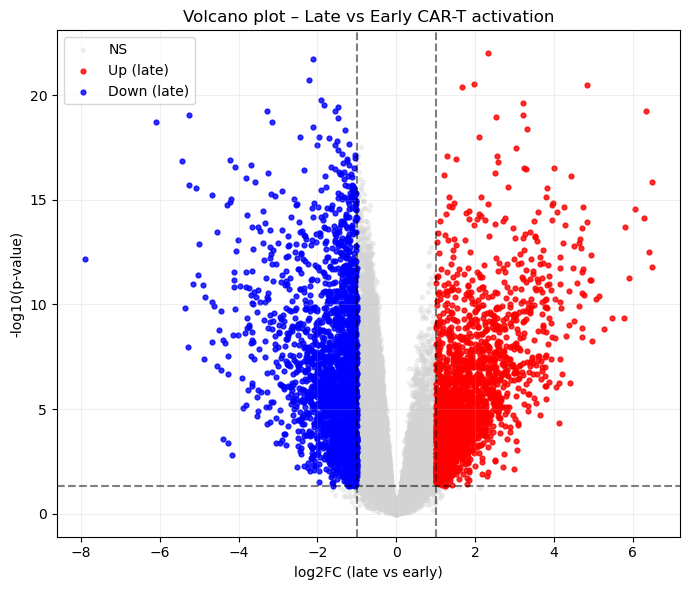

In [35]:
import matplotlib.pyplot as plt
import numpy as np

res = de_late_vs_early.copy()

# basic stats
res["neg_log10_pval"] = -np.log10(res["pval"].clip(lower=1e-300))

# thresholds
fc_thresh = 1.0   # |log2FC| > 1
p_thresh  = 0.05

sig_up   = (res["log2FC"] >= fc_thresh) & (res["pval"] < p_thresh)
sig_down = (res["log2FC"] <= -fc_thresh) & (res["pval"] < p_thresh)

plt.figure(figsize=(7,6))

# non-significant
plt.scatter(res["log2FC"], res["neg_log10_pval"],
            s=8, alpha=0.3, label="NS", color="lightgray")

# up
plt.scatter(res.loc[sig_up, "log2FC"],
            res.loc[sig_up, "neg_log10_pval"],
            s=12, alpha=0.8, label="Up (late)", color="red")

# down
plt.scatter(res.loc[sig_down, "log2FC"],
            res.loc[sig_down, "neg_log10_pval"],
            s=12, alpha=0.8, label="Down (late)", color="blue")

plt.axvline(fc_thresh,  linestyle="--", color="black", alpha=0.5)
plt.axvline(-fc_thresh, linestyle="--", color="black", alpha=0.5)
plt.axhline(-np.log10(p_thresh), linestyle="--", color="black", alpha=0.5)

plt.xlabel("log2FC (late vs early)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano plot – Late vs Early CAR-T activation")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("figures/volcano_late_vs_early.png", dpi=300)
plt.show()


In [36]:
import os
os.makedirs("figures", exist_ok=True)


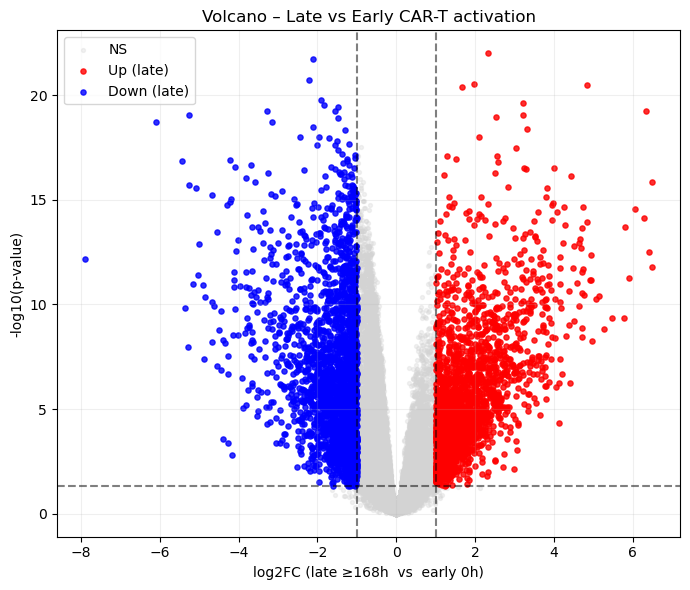

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Work on a copy to avoid messing with the original table
res = de_late_vs_early.copy()

# Guardrail: drop any rows with NaN p-values
res = res.dropna(subset=["pval"])

# -log10(p)
res["neg_log10_pval"] = -np.log10(res["pval"].clip(lower=1e-300))

# Thresholds (you can tweak these later)
fc_thresh = 1.0    # |log2FC| ≥ 1
p_thresh  = 0.05

sig_up   = (res["log2FC"] >= fc_thresh) & (res["pval"] < p_thresh)
sig_down = (res["log2FC"] <= -fc_thresh) & (res["pval"] < p_thresh)

plt.figure(figsize=(7, 6))

# Non-significant
plt.scatter(res["log2FC"], res["neg_log10_pval"],
            s=8, alpha=0.3, color="lightgray", label="NS")

# Upregulated in late
plt.scatter(res.loc[sig_up, "log2FC"],
            res.loc[sig_up, "neg_log10_pval"],
            s=14, alpha=0.8, color="red", label="Up (late)")

# Downregulated in late
plt.scatter(res.loc[sig_down, "log2FC"],
            res.loc[sig_down, "neg_log10_pval"],
            s=14, alpha=0.8, color="blue", label="Down (late)")

# Threshold lines
plt.axvline(fc_thresh,  linestyle="--", color="black", alpha=0.5)
plt.axvline(-fc_thresh, linestyle="--", color="black", alpha=0.5)
plt.axhline(-np.log10(p_thresh), linestyle="--", color="black", alpha=0.5)

plt.xlabel("log2FC (late ≥168h  vs  early 0h)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano – Late vs Early CAR-T activation")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig("figures/volcano_late_vs_early.png", dpi=300)
plt.show()


In [38]:
cd4_mask = metadata["cell_type"] == "CD4"
cd8_mask = metadata["cell_type"] == "CD8"

cd4_samples = expr_df.loc[:, cd4_mask]
cd8_samples = expr_df.loc[:, cd8_mask]


In [39]:
top_genes = (
    de_late_vs_early["log2FC"]
    .abs()
    .sort_values(ascending=False)
    .head(50)
    .index
)


In [40]:
heatmap_matrix = expr_df.loc[top_genes]


In [41]:
from scipy.stats import zscore

heatmap_z = heatmap_matrix.apply(zscore, axis=1)


In [42]:
print("heatmap_matrix shape:", heatmap_matrix.shape)
print(heatmap_matrix.dtypes.head())


heatmap_matrix shape: (50, 60)
CART0077_RNAseq_NgsRun1_001    int64
CART0077_RNAseq_NgsRun1_002    int64
CART0077_RNAseq_NgsRun1_003    int64
CART0077_RNAseq_NgsRun1_004    int64
CART0077_RNAseq_NgsRun1_005    int64
dtype: object


In [43]:
import numpy as np

# heatmap_matrix: genes (rows) x samples (cols)
gene_means = heatmap_matrix.mean(axis=1)
gene_stds  = heatmap_matrix.std(axis=1, ddof=0)

# avoid division by zero
gene_stds_repl = gene_stds.replace(0, np.nan)

heatmap_z = heatmap_matrix.sub(gene_means, axis=0).div(gene_stds_repl, axis=0)

print("heatmap_z shape:", heatmap_z.shape)
print(heatmap_z.dtypes.head())


heatmap_z shape: (50, 60)
CART0077_RNAseq_NgsRun1_001    float64
CART0077_RNAseq_NgsRun1_002    float64
CART0077_RNAseq_NgsRun1_003    float64
CART0077_RNAseq_NgsRun1_004    float64
CART0077_RNAseq_NgsRun1_005    float64
dtype: object


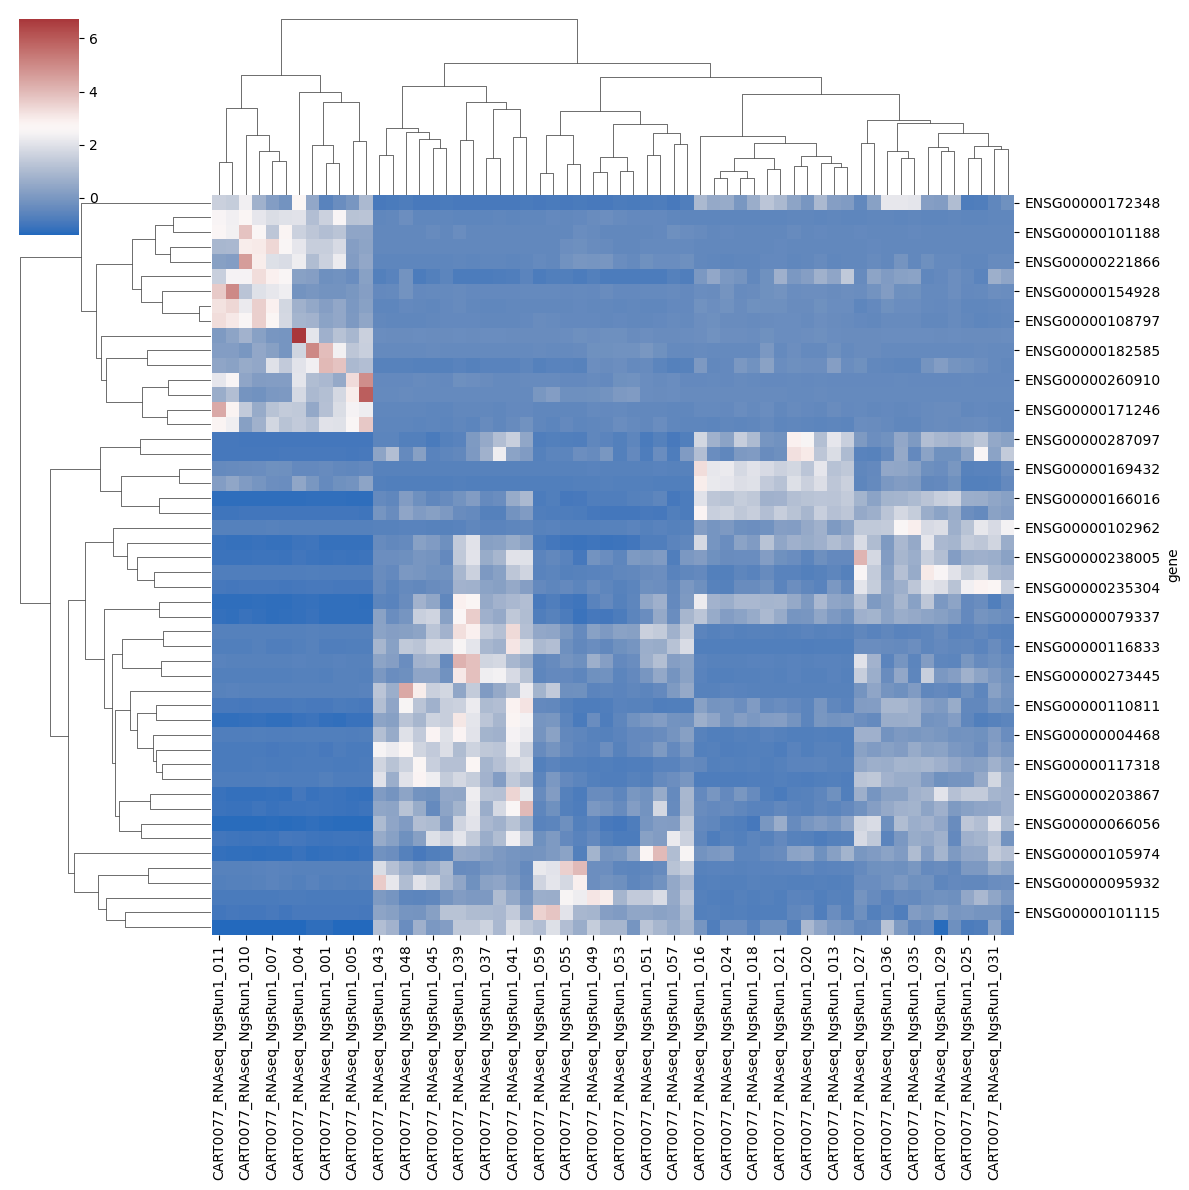

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    heatmap_z,
    cmap="vlag",
    figsize=(12, 12),
    col_cluster=True,
    row_cluster=True,
)

plt.savefig("figures/heatmap_CD4_CD8_late_vs_early.png", dpi=300)
plt.show()


In [45]:
!pip install mygene



In [46]:
import mygene
import pandas as pd
import numpy as np

mg = mygene.MyGeneInfo()

# 1. Strip version numbers (ENSG00000123456.7 → ENSG00000123456)
ensembl_ids = expr_df.index.to_series().str.split(".").str[0]
unique_ensg = ensembl_ids.unique().tolist()

print("Unique Ensembl IDs:", len(unique_ensg))

# 2. Query mygene
out = mg.querymany(
    unique_ensg,
    scopes="ensembl.gene",
    fields=["symbol", "name"],
    species="human"
)

annot = pd.DataFrame(out)
annot.head()


Input sequence provided is already in string format. No operation performed


Unique Ensembl IDs: 60675


35 input query terms found dup hits:	[('ENSG00000228044', 2), ('ENSG00000226506', 2), ('ENSG00000261600', 2), ('ENSG00000234162', 2), ('E
1264 input query terms found no hit:	['ENSG00000238009', 'ENSG00000288531', 'ENSG00000230699', 'ENSG00000241180', 'ENSG00000236948', 'ENS


,query,_id,_score,name,symbol,notfound
0,ENSG00000223972,ENSG00000223972,10.618598,DEAD/H-box helicase 11 like 1 (pseudogene),DDX11L1,NaN
1,ENSG00000227232,ENSG00000227232,10.618598,"WASP family homolog 7, pseudogene",WASH7P,NaN
2,ENSG00000278267,102466751,32.917652,microRNA 6859-1,MIR6859-1,NaN
3,ENSG00000243485,ENSG00000243485,32.917652,MIR1302-2 host gene,MIR1302-2HG,NaN
4,ENSG00000284332,100302278,32.917652,microRNA 1302-2,MIR1302-2,NaN


In [47]:
annot_clean = annot.dropna(subset=["symbol"])
ensg_to_symbol = annot_clean.set_index("query")["symbol"]

print("Mapped:", ensg_to_symbol.shape[0])


Mapped: 45132


In [48]:
# top_genes is a Index of Ensembl IDs
top_ensg = pd.Index(top_genes).to_series().str.split(".").str[0]
top_symbols = top_ensg.map(ensg_to_symbol).dropna().unique()

print("Top symbols:", len(top_symbols))

heatmap_matrix = expr_symbol.loc[top_symbols]

# Z-score per gene (row)
gene_means = heatmap_matrix.mean(axis=1)
gene_stds  = heatmap_matrix.std(axis=1, ddof=0).replace(0, np.nan)

heatmap_z = heatmap_matrix.sub(gene_means, axis=0).div(gene_stds, axis=0)


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    heatmap_z,
    cmap="vlag",
    figsize=(12, 12),
    col_cluster=True,
    row_cluster=True,
)

plt.savefig("figures/heatmap_CD4_CD8_late_vs_early_symbols.png", dpi=300)
plt.show()


In [ ]:
#Rebuild the mapping as a dict
#Start from your annot DataFrame (from mygene):
import pandas as pd

annot_clean = annot.dropna(subset=["symbol"])

# keep only the first hit per Ensembl ID
annot_unique = annot_clean.drop_duplicates(subset=["query"], keep="first")

# build a plain dict: {ENSG_ID: SYMBOL}
ensg_map = dict(zip(annot_unique["query"], annot_unique["symbol"]))

print("Unique Ensembl→symbol entries:", len(ensg_map))


In [ ]:
#Apply the mapping safely

expr_with_ids = expr_df.copy()

# remove version suffix from Ensembl IDs
expr_with_ids["ensembl_clean"] = expr_with_ids.index.to_series().str.split(".").str[0]

# ✅ use the dict, not a pandas Series
expr_with_ids["gene_symbol"] = expr_with_ids["ensembl_clean"].map(ensg_map)

# drop rows that failed to map
expr_with_ids = expr_with_ids.dropna(subset=["gene_symbol"])

# collapse duplicates by averaging expression per symbol
expr_symbol = (
    expr_with_ids
    .drop(columns=["ensembl_clean"])
    .groupby("gene_symbol")
    .mean()
)

print("Old shape:", expr_df.shape)
print("New (symbol) shape:", expr_symbol.shape)


In [ ]:
print(expr_symbol.head())
print(expr_symbol.index[:10])


In [ ]:
import pandas as pd

expr_matrix = pd.read_csv(
    "data/raw/GSE266618_series_matrix.txt",
    sep="\t",
    comment="!",
    index_col=0
)

expr_matrix.shape
expr_matrix.head()


In [49]:
print("X shape:", X.shape)
print("NaNs in X:", np.isnan(X).sum())

print("X_pca shape:", X_pca.shape)
print("NaNs in X_pca:", np.isnan(X_pca).sum())

print("First 5 rows of X_pca:\n", X_pca[:5, :])


X shape: (60, 60675)
NaNs in X: gene
ENSG00000223972    0
ENSG00000227232    0
ENSG00000278267    0
ENSG00000243485    0
ENSG00000284332    0
                  ..
ENSG00000271254    0
ENSG00000275405    0
ENSG00000275987    0
ENSG00000277475    0
ENSG00000268674    0
Length: 60675, dtype: int64
X_pca shape: (60, 2)
NaNs in X_pca: 0
First 5 rows of X_pca:
 [[-68.84369231  80.29391486]
 [-67.76501044  92.02127378]
 [-45.81223694  95.56183372]
 [-65.78403905 101.142589  ]
 [-78.33946669  67.97417889]]
